<a href="https://colab.research.google.com/github/AileenLavelle/PBC_Object_Detection/blob/main/Recreating_Roboflow_workflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Trying to recreate the pre-processing I did in Roboflow

In [1]:
!pip install -q ultralytics opencv-python-headless
print("Done!")

  You can safely remove it manually.
  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
chromadb 0.4.10 requires pydantic<2.0,>=1.9, but you have pydantic 2.12.0 which is incompatible.
datasets 4.3.0 requires dill<0.4.1,>=0.3.0, but you have dill 0.4.1 which is incompatible.
datasets 4.3.0 requires fsspec[http]<=2025.9.0,>=2023.1.0, but you have fsspec 2025.12.0 which is incompatible.
langchain 0.1.5 requires langchain-core<0.2,>=0.1.16, but you have langchain-core 0.3.79 which is incompatible.
langchain 0.1.5 requires langsmith<0.1,>=0.0.83, but you have langsmith 0.4.34 which is incompatible.
langchain 0.1.5 requires numpy<2,>=1, but you have numpy 2.2.6 which is incompatible.
langchain-community 0.0.18 requires langchain-core<0.2,>=0.1.19, but you have langchain-core 0.3.79 which is incompatible.
langchain-community 0.0.18 r

## Step 2: Import Libraries

In [2]:
import os
import json
import shutil
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt

## Step 3: Configure Paths


In [3]:
#setting paths
COCO_JSON = "/blue/bsc4892/aileenlavelle/PBC_Object_Detection/Jupiter_Inlet/_annotations.coco.json"
IMAGES_DIR = "/blue/bsc4892/aileenlavelle/PBC_Object_Detection/Jupiter_Inlet"
OUTPUT_DIR = "/blue/bsc4892/aileenlavelle/PBC_Object_Detection/Jupiter_Inlet/jupiter_inlet_yolo"

# Roboflow preprocessing settings
APPLY_PREPROCESSING = True  # Set to False if images are already preprocessed
CROP_HORIZONTAL = (0.33, 1.0)   # 33-100% horizontal
CROP_VERTICAL = (0.28, 0.49)    # 28-49% vertical
RESIZE_TO = (2048, 800)         # Width x Height

print(f"COCO JSON: {COCO_JSON}")
print(f"Images dir: {IMAGES_DIR}")
print(f"Output dir: {OUTPUT_DIR}")
print(f"Apply preprocessing: {APPLY_PREPROCESSING}")

COCO JSON: /blue/bsc4892/aileenlavelle/PBC_Object_Detection/Jupiter_Inlet/_annotations.coco.json
Images dir: /blue/bsc4892/aileenlavelle/PBC_Object_Detection/Jupiter_Inlet
Output dir: /blue/bsc4892/aileenlavelle/PBC_Object_Detection/Jupiter_Inlet/jupiter_inlet_yolo
Apply preprocessing: True


## Step 4: Load COCO Annotations

In [4]:
def load_coco_json(json_path):
    """Safely load COCO JSON"""
    print(f"Loading: {json_path}")

    for encoding in ['utf-8-sig', 'utf-8', 'latin-1']:
        try:
            with open(json_path, 'r', encoding=encoding) as f:
                content = f.read().strip()
            if content.startswith('\ufeff'):
                content = content[1:]
            data = json.loads(content)
            print(f"Loaded successfully ({encoding})")
            return data
        except Exception as e:
            continue
    raise ValueError("Could not parse JSON")

coco_data = load_coco_json(COCO_JSON)

print(f"\n{'='*50}")
print(f"Dataset Summary:")
print(f"{'='*50}")
print(f"  Images: {len(coco_data['images'])}")
print(f"  Annotations: {len(coco_data['annotations'])}")
print(f"  Categories: {coco_data['categories']}")

if coco_data['images']:
    img = coco_data['images'][0]
    print(f"  Original image size: {img['width']} x {img['height']}")

    if img['width'] > 2048 or img['height'] > 800:
        print(f"\ Images are RAW (not preprocessed by Roboflow)")
        print(f"   Will apply preprocessing: crop + resize to {RESIZE_TO}")

Loading: /blue/bsc4892/aileenlavelle/PBC_Object_Detection/Jupiter_Inlet/_annotations.coco.json
Loaded successfully (utf-8-sig)

Dataset Summary:
  Images: 813
  Annotations: 3004
  Categories: [{'id': 0, 'name': 'Boat', 'supercategory': 'none'}, {'id': 1, 'name': 'Boat', 'supercategory': 'Boat'}]
  Original image size: 4352 x 3264
\ Images are RAW (not preprocessed by Roboflow)
   Will apply preprocessing: crop + resize to (2048, 800)


## Step 5: Find Source Images

In [5]:
def find_all_source_images(base_dir, exclude_patterns=['yolo', 'output', 'labels']):
    """
    Find all source images, excluding output directories.
    Returns a dict mapping filename -> full path
    """
    base_path = Path(base_dir)
    all_images = {}

    for ext in ['*.jpg', '*.jpeg', '*.png', '*.JPG', '*.JPEG', '*.PNG']:
        for f in base_path.rglob(ext):
            # Skip output/yolo directories
            path_str = str(f).lower()
            if any(pattern in path_str for pattern in exclude_patterns):
                continue
            all_images[f.name] = f

    return all_images

# Find images
source_images = find_all_source_images(IMAGES_DIR)
print(f"Found {len(source_images)} source images")

# Show some examples
if source_images:
    examples = list(source_images.items())[:3]
    print("\nExample images found:")
    for name, path in examples:
        print(f"  {name} -> {path}")

Found 807 source images

Example images found:
  o101205w_jpg.rf.T8ZSWtvTS4QHEMZesJZb.jpg -> /blue/bsc4892/aileenlavelle/PBC_Object_Detection/Jupiter_Inlet/o101205w_jpg.rf.T8ZSWtvTS4QHEMZesJZb.jpg
  s221404g_jpg.rf.fKLlL9Gj2zOk8nZG2HIV.jpg -> /blue/bsc4892/aileenlavelle/PBC_Object_Detection/Jupiter_Inlet/s221404g_jpg.rf.fKLlL9Gj2zOk8nZG2HIV.jpg
  s291726i_jpg.rf.rJYR58W1hRENe7HZfA9R.jpg -> /blue/bsc4892/aileenlavelle/PBC_Object_Detection/Jupiter_Inlet/s291726i_jpg.rf.rJYR58W1hRENe7HZfA9R.jpg


## Step 6: Preprocessing Function

This applies the same preprocessing I used in Roboflow:
- Static Crop: 33-100% Horizontal, 28-49% Vertical
- Resize: Stretch to 2048x800

In [6]:
def apply_roboflow_preprocessing(image, crop_h=(0.33, 1.0), crop_v=(0.28, 0.49), resize_to=(2048, 800)):
    """
    Apply Roboflow's preprocessing to an image.

    Args:
        image: numpy array (BGR)
        crop_h: (start, end) horizontal crop percentages
        crop_v: (start, end) vertical crop percentages
        resize_to: (width, height) final size

    Returns:
        Preprocessed image, crop_info dict for adjusting bboxes
    """
    h, w = image.shape[:2]

    # Calculate crop coordinates
    x1 = int(w * crop_h[0])
    x2 = int(w * crop_h[1])
    y1 = int(h * crop_v[0])
    y2 = int(h * crop_v[1])

    # Crop
    cropped = image[y1:y2, x1:x2]
    crop_h_actual, crop_w_actual = cropped.shape[:2]

    # Resize
    resized = cv2.resize(cropped, resize_to, interpolation=cv2.INTER_LINEAR)

    # Info needed to transform bounding boxes
    crop_info = {
        'orig_w': w,
        'orig_h': h,
        'crop_x1': x1,
        'crop_y1': y1,
        'crop_w': crop_w_actual,
        'crop_h': crop_h_actual,
        'final_w': resize_to[0],
        'final_h': resize_to[1],
    }

    return resized, crop_info


def transform_bbox(bbox, crop_info):
    """
    Transform a COCO bbox from original image coords to preprocessed image coords.

    Args:
        bbox: [x_min, y_min, width, height] in original image coords
        crop_info: dict from apply_roboflow_preprocessing

    Returns:
        Transformed bbox or None if bbox is outside crop region
    """
    x_min, y_min, bw, bh = [float(v) for v in bbox]
    x_max = x_min + bw
    y_max = y_min + bh

    # Crop coordinates
    cx1, cy1 = crop_info['crop_x1'], crop_info['crop_y1']
    cx2 = cx1 + crop_info['crop_w']
    cy2 = cy1 + crop_info['crop_h']

    # Check if bbox is completely outside crop region
    if x_max <= cx1 or x_min >= cx2 or y_max <= cy1 or y_min >= cy2:
        return None  # bbox outside crop

    # Clip bbox to crop region
    x_min = max(x_min, cx1)
    y_min = max(y_min, cy1)
    x_max = min(x_max, cx2)
    y_max = min(y_max, cy2)

    # Translate to crop coordinates
    x_min -= cx1
    y_min -= cy1
    x_max -= cx1
    y_max -= cy1

    # Scale to final size
    scale_x = crop_info['final_w'] / crop_info['crop_w']
    scale_y = crop_info['final_h'] / crop_info['crop_h']

    x_min *= scale_x
    y_min *= scale_y
    x_max *= scale_x
    y_max *= scale_y

    # Convert back to [x, y, w, h]
    new_bbox = [x_min, y_min, x_max - x_min, y_max - y_min]

    # Skip tiny boxes (likely cut off by crop)
    if new_bbox[2] < 2 or new_bbox[3] < 2:
        return None

    return new_bbox

print("Preprocessing functions defined!")

Preprocessing functions defined!


## Step 7: Convert COCO to YOLO (with preprocessing)

In [7]:
def coco_to_yolo_with_preprocessing(
    coco_data,
    source_images,
    output_dir,
    apply_preprocessing=True,
    crop_h=(0.33, 1.0),
    crop_v=(0.28, 0.49),
    resize_to=(2048, 800),
    train_split=0.8
):
    """
    Convert COCO to YOLO format with optional Roboflow preprocessing.
    """
    output_path = Path(output_dir)

    # Clean output directory
    if output_path.exists():
        shutil.rmtree(output_path)

    # Create directories
    for split in ['train', 'val']:
        (output_path / 'images' / split).mkdir(parents=True, exist_ok=True)
        (output_path / 'labels' / split).mkdir(parents=True, exist_ok=True)

    # Build mappings
    image_map = {img['id']: img for img in coco_data['images']}

    annotations_by_image = {}
    for ann in coco_data['annotations']:
        img_id = ann['image_id']
        if img_id not in annotations_by_image:
            annotations_by_image[img_id] = []
        annotations_by_image[img_id].append(ann)

    # Train/val split
    image_ids = list(image_map.keys())
    split_idx = int(len(image_ids) * train_split)
    train_ids = set(image_ids[:split_idx])

    print(f"Train: {len(train_ids)}, Val: {len(image_ids) - len(train_ids)}")
    print(f"Preprocessing: {apply_preprocessing}")

    processed = 0
    missing = 0
    skipped_anns = 0

    for img_id, img_info in image_map.items():
        orig_width = img_info['width']
        orig_height = img_info['height']
        img_filename = img_info['file_name']
        basename = Path(img_filename).name

        # Find source image
        src_path = None
        if basename in source_images:
            src_path = source_images[basename]
        elif img_filename in source_images:
            src_path = source_images[img_filename]

        if src_path is None:
            missing += 1
            if missing <= 5:
                print(f"  Missing: {img_filename}")
            continue

        split = 'train' if img_id in train_ids else 'val'

        # Process image
        image = cv2.imread(str(src_path))
        if image is None:
            missing += 1
            continue

        if apply_preprocessing:
            # Apply Roboflow preprocessing
            image, crop_info = apply_roboflow_preprocessing(
                image, crop_h, crop_v, resize_to
            )
            final_w, final_h = resize_to
        else:
            crop_info = None
            final_h, final_w = image.shape[:2]

        # Save image
        dst_img = output_path / 'images' / split / basename
        cv2.imwrite(str(dst_img), image)

        # Convert annotations
        yolo_lines = []
        if img_id in annotations_by_image:
            for ann in annotations_by_image[img_id]:
                bbox = ann['bbox']  # [x_min, y_min, w, h]

                if apply_preprocessing and crop_info:
                    # Transform bbox to preprocessed coordinates
                    bbox = transform_bbox(bbox, crop_info)
                    if bbox is None:
                        skipped_anns += 1
                        continue

                x_min, y_min, bw, bh = [float(v) for v in bbox]

                # Convert to YOLO format (normalized center coords)
                x_center = (x_min + bw / 2) / final_w
                y_center = (y_min + bh / 2) / final_h
                w_norm = bw / final_w
                h_norm = bh / final_h

                # Clamp to [0, 1]
                x_center = max(0, min(1, x_center))
                y_center = max(0, min(1, y_center))
                w_norm = max(0, min(1, w_norm))
                h_norm = max(0, min(1, h_norm))

                yolo_lines.append(f"0 {x_center:.6f} {y_center:.6f} {w_norm:.6f} {h_norm:.6f}")

        # Save labels
        label_path = output_path / 'labels' / split / (Path(basename).stem + '.txt')
        with open(label_path, 'w') as f:
            f.write('\n'.join(yolo_lines))

        processed += 1

        if processed % 50 == 0:
            print(f"  Processed {processed} images...")

    print(f"\n{'='*50}")
    print(f"Conversion complete!")
    print(f"  Processed: {processed}")
    print(f"  Missing: {missing}")
    if apply_preprocessing:
        print(f"  Annotations outside crop: {skipped_anns}")
    print(f"{'='*50}")

    # Create data.yaml
    data_yaml = f"""path: {output_path.absolute()}
train: images/train
val: images/val
nc: 1
names:
  0: Boat
"""

    yaml_path = output_path / 'data.yaml'
    with open(yaml_path, 'w') as f:
        f.write(data_yaml)

    print(f"\nCreated: {yaml_path}")
    return str(yaml_path)


# Run conversion
data_yaml_path = coco_to_yolo_with_preprocessing(
    coco_data,
    source_images,
    OUTPUT_DIR,
    apply_preprocessing=APPLY_PREPROCESSING,
    crop_h=CROP_HORIZONTAL,
    crop_v=CROP_VERTICAL,
    resize_to=RESIZE_TO,
)

Train: 650, Val: 163
Preprocessing: True


Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file


  Processed 50 images...


Premature end of JPEG file
Premature end of JPEG file


  Processed 100 images...


...

  Processed 700 images...


Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
P

  Processed 750 images...
  Missing: s081658d_jpg.rf.1sBuUsTyae5eCee8xV1s.jpg


Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file


  Processed 800 images...

Conversion complete!
  Processed: 805
  Missing: 8
  Annotations outside crop: 329

Created: /blue/bsc4892/aileenlavelle/PBC_Object_Detection/Jupiter_Inlet/jupiter_inlet_yolo/data.yaml


## Step 8: Verify Conversion

In [8]:
# Count files
train_imgs = list(Path(OUTPUT_DIR).glob('images/train/*'))
val_imgs = list(Path(OUTPUT_DIR).glob('images/val/*'))
train_labels = list(Path(OUTPUT_DIR).glob('labels/train/*'))
val_labels = list(Path(OUTPUT_DIR).glob('labels/val/*'))

print(f"Train images: {len(train_imgs)}")
print(f"Val images: {len(val_imgs)}")
print(f"Train labels: {len(train_labels)}")
print(f"Val labels: {len(val_labels)}")

# Check image dimensions
if train_imgs:
    sample_img = cv2.imread(str(train_imgs[0]))
    print(f"\nSample image size: {sample_img.shape[1]} x {sample_img.shape[0]}")
    print(f"Expected size: {RESIZE_TO[0]} x {RESIZE_TO[1]}")

Train images: 646
Val images: 159
Train labels: 646
Val labels: 159

Sample image size: 2048 x 800
Expected size: 2048 x 800


## Step 9: Visualize a Sample (with bounding boxes)

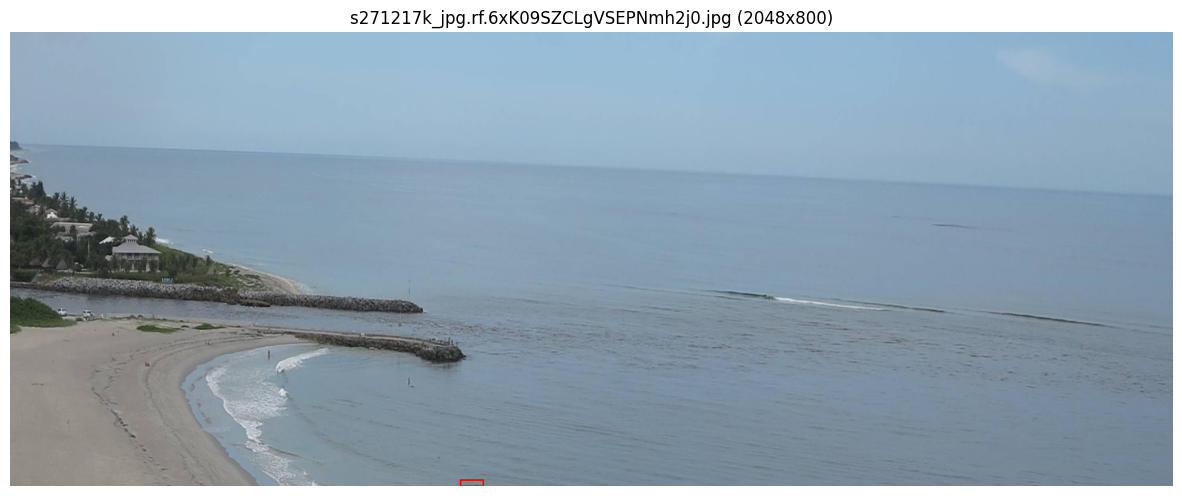

In [9]:
def visualize_sample(output_dir, split='train'):
    """Visualize a random sample with bounding boxes"""
    output_path = Path(output_dir)

    # Get a sample
    images = list((output_path / 'images' / split).glob('*'))
    if not images:
        print("No images found!")
        return

    import random
    sample_img_path = random.choice(images)
    label_path = output_path / 'labels' / split / (sample_img_path.stem + '.txt')

    # Load image
    img = cv2.imread(str(sample_img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]

    # Load and draw labels
    if label_path.exists():
        with open(label_path) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) == 5:
                    _, xc, yc, bw, bh = map(float, parts)
                    # Convert to pixel coords
                    x1 = int((xc - bw/2) * w)
                    y1 = int((yc - bh/2) * h)
                    x2 = int((xc + bw/2) * w)
                    y2 = int((yc + bh/2) * h)
                    cv2.rectangle(img, (x1, y1), (x2, y2), (255, 0, 0), 2)

    plt.figure(figsize=(15, 6))
    plt.imshow(img)
    plt.title(f"{sample_img_path.name} ({w}x{h})")
    plt.axis('off')
    plt.show()

visualize_sample(OUTPUT_DIR, 'train')

## Step 10: Train YOLO26s

In [10]:
from ultralytics import YOLO
# Load model
model = YOLO('yolo26s.pt')

results = model.train(
    data=data_yaml_path,
    epochs=100,            
    imgsz=512,            # Smaller image size (faster)
    batch=50,
    rect=True,         
    
    mosaic=0.5,
    scale=0.2,
    fliplr=0.5,
    flipud=0.0,
    
    patience=50,
    save=True,
    plots=True,
    
    project='jupiter_inlet',
    name='train_test',
)

# Train
#results = model.train(
  #  data=data_yaml_path,
  #  epochs=100,
  #  imgsz=2048,           # Match preprocessed width
# batch=4,              # Reduce if OOM
#    rect=True,            # For non-square images
#    device=0,

    # Small object optimizations
 #   mosaic=0.5,
  #  scale=0.2,

    # Augmentations
  #  fliplr=0.5,
 #   flipud=0.0,

    # Training
 #   patience=50,
  #  save=True,
 #   plots=True,

 #   project='jupiter_inlet',
  #  name='train',
#)

New https://pypi.org/project/ultralytics/8.4.21 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.14 🚀 Python-3.10.12 torch-2.10.0+cu128 CUDA:0 (NVIDIA B200, 182642MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=50, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/blue/bsc4892/aileenlavelle/PBC_Object_Detection/Jupiter_Inlet/jupiter_inlet_yolo/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=512, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26s.pt,

/home/aileenlavelle/.local/lib/python3.10/site-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/home/aileenlavelle/.local/lib/python3.10/site-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


val: Fast image access ✅ (ping: 2.3±3.3 ms, read: 225.4±57.9 MB/s, size: 299.5 KB)
val: Scanning /blue/bsc4892/aileenlavelle/PBC_Object_Detection/Jupiter_Inlet/jupiter_inlet_yolo/labels/val... 159 images, 8 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 159/159 1.2Kit/s 0.1s<0.1s
val: New cache created: /blue/bsc4892/aileenlavelle/PBC_Object_Detection/Jupiter_Inlet/jupiter_inlet_yolo/labels/val.cache


/home/aileenlavelle/.local/lib/python3.10/site-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 16 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/home/aileenlavelle/.local/lib/python3.10/site-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 16 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.002, momentum=0.9) with parameter groups 114 weight(decay=0.0), 126 weight(decay=0.000390625), 126 bias(decay=0.0)
Plotting labels to /blue/bsc4892/aileenlavelle/PBC_Object_Detection/runs/detect/jupiter_inlet/train_test12/labels.jpg... 
Image sizes 512 train, 512 val
Using 8 dataloader workers
Logging results to /blue/bsc4892/aileenlavelle/PBC_Object_Detection/runs/detect/jupiter_inlet/train_test12
Starting training for 100 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      1/100      4.11G       3.14      4.394   0.005043        122        512: 100% ━━━━━━━━━━━━ 13/13 1.6s/it 20.9s0.3s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 1.7s/it 3.5s6.1s
                   all        159        538      0.162      0

/home/aileenlavelle/.local/lib/python3.10/site-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()



      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     91/100      4.76G      2.017     0.8752   0.002015        106        512: 100% ━━━━━━━━━━━━ 13/13 4.5it/s 2.9s0.1s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 7.4it/s 0.3s0.5s
                   all        159        538      0.693      0.556      0.581      0.222

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     92/100      4.76G      2.022     0.8622   0.002022        101        512: 100% ━━━━━━━━━━━━ 13/13 8.3it/s 1.6s0.1s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 4.8it/s 0.4s0.8s
                   all        159        538      0.681      0.554      0.584      0.229

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     93/100      4.76G      2.012      0.868   0.002011        112        512: 100% ━━━

ModuleNotFoundError: No module named 'numpy.char'

## Step 11: Validate

In [11]:
from ultralytics import YOLO
best_weights = '/blue/bsc4892/aileenlavelle/PBC_Object_Detection/runs/detect/jupiter_inlet/train_test8/weights/best.pt'
model = YOLO(best_weights)

metrics = model.val(
    data=data_yaml_path,
    imgsz=2048,
    rect=True,
    conf=0.001,
    iou=0.5,
)

print("\n" + "=" * 50)
print("YOUR RESULTS:")
print(f"  mAP@50:    {metrics.box.map50:.1%}")
print(f"  Precision: {metrics.box.mp:.1%}")
print(f"  Recall:    {metrics.box.mr:.1%}")
print("=" * 50)
print("ROBOFLOW TARGET:")
print("  mAP@50:    83.8%")
print("  Precision: 86.0%")
print("  Recall:    76.0%")
print("=" * 50)

Ultralytics 8.4.14 🚀 Python-3.10.12 torch-2.10.0+cu128 CUDA:0 (NVIDIA B200, 182642MiB)
YOLO26s summary (fused): 122 layers, 9,465,567 parameters, 0 gradients, 20.5 GFLOPs
val: Fast image access ✅ (ping: 0.2±0.1 ms, read: 299.3±25.8 MB/s, size: 326.0 KB)
val: Scanning /blue/bsc4892/aileenlavelle/PBC_Object_Detection/Jupiter_Inlet/jupiter_inlet_yolo/labels/val.cache... 159 images, 8 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 159/159 35.1Mit/s 0.0s


/home/aileenlavelle/.local/lib/python3.10/site-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/home/aileenlavelle/.local/lib/python3.10/site-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 10/10 3.1it/s 3.3s.3ss
                   all        159        538      0.881       0.79      0.857      0.453
Speed: 4.3ms preprocess, 5.3ms inference, 0.0ms loss, 0.2ms postprocess per image
Results saved to /blue/bsc4892/aileenlavelle/PBC_Object_Detection/runs/detect/val8

YOUR RESULTS:
  mAP@50:    85.7%
  Precision: 88.1%
  Recall:    79.0%
ROBOFLOW TARGET:
  mAP@50:    83.8%
  Precision: 86.0%
  Recall:    76.0%


## Step 12: Test Inference

Testing: /blue/bsc4892/aileenlavelle/PBC_Object_Detection/Jupiter_Inlet/jupiter_inlet_yolo/images/val/s220916q_jpg.rf.Nu2sm7SinivUtWbCwdat.jpg

image 1/1 /blue/bsc4892/aileenlavelle/PBC_Object_Detection/Jupiter_Inlet/jupiter_inlet_yolo/images/val/s220916q_jpg.rf.Nu2sm7SinivUtWbCwdat.jpg: 800x2048 1 Boat, 52.7ms
Speed: 4.4ms preprocess, 52.7ms inference, 1.0ms postprocess per image at shape (1, 3, 800, 2048)
Results saved to /blue/bsc4892/aileenlavelle/PBC_Object_Detection/runs/detect/predict2
Detected 1 boats


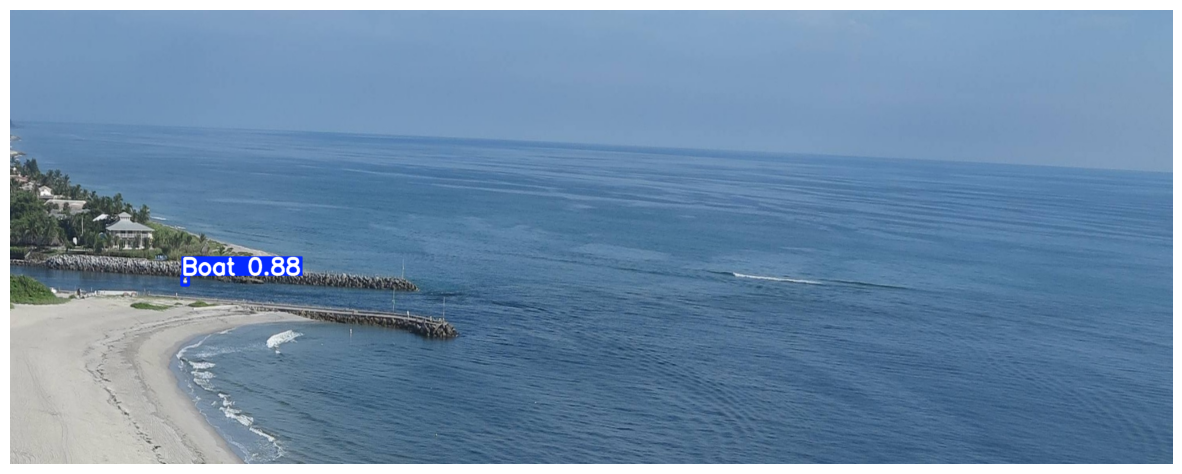

In [12]:
# Get a test image
test_images = list(Path(OUTPUT_DIR).glob('images/val/*.jpg'))

if test_images:
    test_img = str(test_images[0])
    print(f"Testing: {test_img}")

    results = model.predict(
        source=test_img,
        imgsz=2048,
        conf=0.25,
        save=True,
    )

    print(f"Detected {len(results[0].boxes)} boats")

    result_img = results[0].plot()
    plt.figure(figsize=(15, 6))
    plt.imshow(cv2.cvtColor(result_img, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()

## Step 13: Download Model

In [13]:
import os
from pathlib import Path

# Find the best.pt file
for p in Path('/blue/bsc4892/aileenlavelle').rglob('best.pt'):
    print(p)

/blue/bsc4892/aileenlavelle/PBC_Object_Detection/runs/detect/jupiter_inlet_model_vs_aug/add_rotation/weights/best.pt
/blue/bsc4892/aileenlavelle/PBC_Object_Detection/runs/detect/jupiter_inlet_model_vs_aug/add_copy_paste/weights/best.pt
/blue/bsc4892/aileenlavelle/PBC_Object_Detection/runs/detect/jupiter_inlet_model_vs_aug/larger_model_yolo26m/weights/best.pt
/blue/bsc4892/aileenlavelle/PBC_Object_Detection/runs/detect/jupiter_inlet_model_vs_aug/stronger_mosaic/weights/best.pt
/blue/bsc4892/aileenlavelle/PBC_Object_Detection/runs/detect/jupiter_inlet_model_vs_aug/add_mixup/weights/best.pt
/blue/bsc4892/aileenlavelle/PBC_Object_Detection/runs/detect/jupiter_inlet_model_vs_aug/stronger_mosaic2/weights/best.pt
/blue/bsc4892/aileenlavelle/PBC_Object_Detection/runs/detect/jupiter_inlet_experiments_v2/796img_imgsz_1024/weights/best.pt
/blue/bsc4892/aileenlavelle/PBC_Object_Detection/runs/detect/jupiter_inlet_experiments_v2/796img_baseline_s_640_e1002/weights/best.pt
/blue/bsc4892/aileenlavell